In [1]:
# =========================================================
# NLP TEXT CLASSIFICATION - CODE ACUAN
# Berdasarkan:
# - Preprocessing and Vectorization.pdf
# - Tugas Besar NLP.pdf
#
# Target:
# - 3 kelas: ekonomi, entertainment, teknologi
# - Eksperimen:
#   1) TF-IDF + Naive Bayes
#   2) TF-IDF + SVM
#   3) FastText + SVM
#   4) IndoBERT fine-tuning
# =========================================================

# =========================
# 0. INSTALL (JIKA PERLU)
# =========================
# Jalankan hanya jika environment belum memiliki package-nya
# !pip install -q scikit-learn pandas numpy matplotlib seaborn nltk Sastrawi gensim transformers datasets accelerate torch joblib

In [2]:
# =========================
# 1. IMPORT LIBRARY
# =========================
import re
import string
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import FastText

warnings.filterwarnings("ignore")

In [3]:
# =========================
# 2. SET RANDOM SEED
# =========================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [4]:
# =========================
# 3. DOWNLOAD NLTK RESOURCE
# =========================
# Pada beberapa environment NLTK terbaru, 'punkt_tab' diperlukan.
# Jika gagal, 'punkt' tetap dicoba.
try:
    nltk.download("punkt_tab")
except Exception:
    pass

try:
    nltk.download("punkt")
except Exception:
    pass

try:
    nltk.download("stopwords")
except Exception:
    pass

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [7]:
# =========================
# 4. PATH DAN KONFIGURASI
# =========================
DATA_PATH = Path("dataset/dataset.csv")   # ubah sesuai lokasi dataset Anda
TEXT_COL = "tweet"                            # ubah kalau nama kolom teks berbeda
LABEL_COL = "category"                          # ubah kalau nama kolom label berbeda

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

In [8]:
# =========================
# 5. LOAD DATASET
# =========================
df = pd.read_csv(DATA_PATH)

# pastikan kolom ada
assert TEXT_COL in df.columns, f"Kolom teks '{TEXT_COL}' tidak ditemukan."
assert LABEL_COL in df.columns, f"Kolom label '{LABEL_COL}' tidak ditemukan."

# buang data kosong
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).copy()

# ubah ke string
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Jumlah data:", len(df))
print(df.head())

Jumlah data: 48704
                                               tweet       category
0  Nest Protect mendapat penarikan kembali dan pe...     Technology
1                 PS4 vs. Xbox One: 6 Bulan Kemudian     Technology
2                                   Pertemuan Gereja  Entertainment
3  Facebook: Kami "tidak punya rencana" untuk men...     Technology
4  Kudeta di Thailand memicu pembatalan pemesanan...  Entertainment


In [9]:
# =========================
# 6. ENCODING LABEL
# =========================
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df[LABEL_COL])

class_names = list(le.classes_)
print("Class names:", class_names)

Class names: ['Economy', 'Entertainment', 'Technology']


In [10]:
# =========================
# 7. PREPROCESSING UNTUK MODEL KLASIK
#    (TF-IDF / FastText)
# =========================

stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

# tambahan stopword umum Twitter / dataset informal
extra_stopwords = {
    "rt", "via", "yg", "dgn", "nya", "nih", "deh", "dong", "sih",
    "lah", "kok", "ya", "ga", "gak", "nggak", "aja", "dll", "dsb"
}
indonesian_stopwords |= extra_stopwords

stemmer_factory = StemmerFactory()
indo_stemmer = stemmer_factory.create_stemmer()

def clean_basic_text(text: str) -> str:
    """
    Pembersihan awal:
    - lowercase
    - hapus URL
    - hapus mention
    - hapus karakter non-alfanumerik tertentu
    - rapikan spasi
    """
    text = str(text).lower()

    # hapus url
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # hapus mention
    text = re.sub(r"@\w+", " ", text)

    # hapus hashtag symbol tapi sisakan katanya
    text = text.replace("#", " ")

    # hapus karakter selain huruf/angka/spasi
    # (emoji akan ikut hilang; kalau mau dipertahankan, ubah regex ini)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_classical(text: str) -> str:
    """
    Pipeline sesuai PDF acuan:
    1) Lowercase
    2) Remove URL
    3) Remove punctuation/special char
    4) Tokenization
    5) Stopword removal
    6) Stemming Bahasa Indonesia
    """
    text = clean_basic_text(text)
    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in indonesian_stopwords and len(t) > 1]
    tokens = [indo_stemmer.stem(t) for t in tokens]
    tokens = [t for t in tokens if t.strip()]

    return " ".join(tokens)

# contoh uji
sample = "Saya suka teknologi AI! Cek https://openai.com #AI #teknologi"
print("Before :", sample)
print("After  :", preprocess_classical(sample))

# terapkan preprocessing
df["text_clean"] = df[TEXT_COL].apply(preprocess_classical)

print(df[[TEXT_COL, "text_clean", LABEL_COL]].head())

Before : Saya suka teknologi AI! Cek https://openai.com #AI #teknologi
After  : suka teknologi ai cek ai teknologi
                                               tweet  \
0  Nest Protect mendapat penarikan kembali dan pe...   
1                 PS4 vs. Xbox One: 6 Bulan Kemudian   
2                                   Pertemuan Gereja   
3  Facebook: Kami "tidak punya rencana" untuk men...   
4  Kudeta di Thailand memicu pembatalan pemesanan...   

                                          text_clean       category  
0       nest protect dapat tari baru perangkat lunak     Technology  
1                     ps4 vs xbox one bulan kemudian     Technology  
2                                        temu gereja  Entertainment  
3    facebook punya rencana desain ulang oculus rift     Technology  
4  kudeta thailand picu batal mesan baru turis ne...  Entertainment  


In [11]:
# =========================
# 8. SPLIT DATA
# =========================
X = df["text_clean"].values
y = df["label_encoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 38963
Test size : 9741


In [12]:
# =========================
# 9. FUNGSI EVALUASI
# =========================
def evaluate_model(model, X_test, y_test, class_names, title="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"\n=== {title} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }


=== TF-IDF + Naive Bayes ===
Accuracy : 0.9242
Precision: 0.9222
Recall   : 0.9169
F1-score : 0.9192

Classification Report:
               precision    recall  f1-score   support

      Economy       0.91      0.90      0.91      2954
Entertainment       0.94      0.98      0.96      3989
   Technology       0.92      0.87      0.89      2798

     accuracy                           0.92      9741
    macro avg       0.92      0.92      0.92      9741
 weighted avg       0.92      0.92      0.92      9741



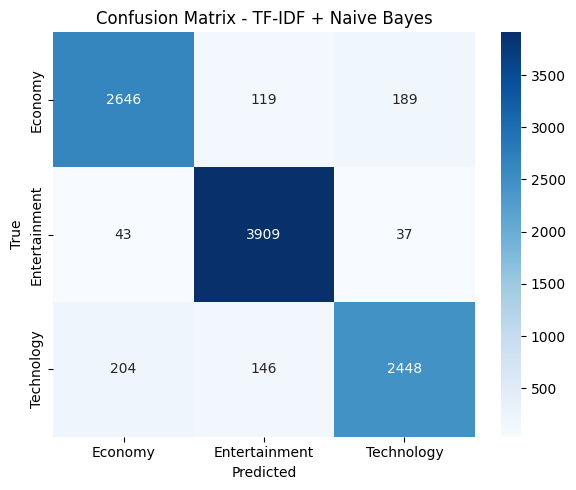

['models\\tfidf_naive_bayes.joblib']

In [13]:
# =========================
# 10. EKSPERIMEN 1
#     TF-IDF + NAIVE BAYES
# =========================
tfidf_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),   # sesuai requirement n-grams
        min_df=1,
        max_df=0.95
    )),
    ("clf", MultinomialNB())
])

tfidf_nb.fit(X_train, y_train)
result_tfidf_nb = evaluate_model(
    tfidf_nb, X_test, y_test, class_names, title="TF-IDF + Naive Bayes"
)

joblib.dump(tfidf_nb, MODEL_DIR / "tfidf_naive_bayes.joblib")


=== TF-IDF + SVM ===
Accuracy : 0.9391
Precision: 0.9351
Recall   : 0.9346
F1-score : 0.9348

Classification Report:
               precision    recall  f1-score   support

      Economy       0.92      0.91      0.92      2954
Entertainment       0.97      0.97      0.97      3989
   Technology       0.91      0.92      0.92      2798

     accuracy                           0.94      9741
    macro avg       0.94      0.93      0.93      9741
 weighted avg       0.94      0.94      0.94      9741



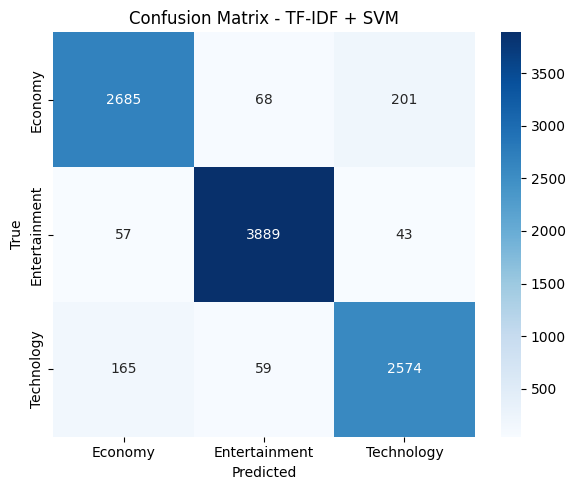

['models\\tfidf_svm.joblib']

In [14]:
# =========================
# 11. EKSPERIMEN 2
#     TF-IDF + SVM
# =========================
tfidf_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95
    )),
    ("clf", SVC(kernel="linear", C=1.0, probability=True, random_state=RANDOM_SEED))
])

tfidf_svm.fit(X_train, y_train)
result_tfidf_svm = evaluate_model(
    tfidf_svm, X_test, y_test, class_names, title="TF-IDF + SVM"
)

joblib.dump(tfidf_svm, MODEL_DIR / "tfidf_svm.joblib")

In [15]:
# =========================
# 12. FASTTEXT UNTUK REPRESENTASI KALIMAT
# =========================
# Untuk proyek tugas, lebih aman melatih FastText dari dataset sendiri
# dibanding mengunduh model sangat besar.

def tokenize_for_fasttext(text: str):
    text = clean_basic_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in indonesian_stopwords and len(t) > 1]
    tokens = [indo_stemmer.stem(t) for t in tokens if t.strip()]
    return tokens

tokenized_corpus = [tokenize_for_fasttext(t) for t in df[TEXT_COL].astype(str).tolist()]

# split dulu untuk mencegah data leakage pada FastText jika ingin lebih rapi
X_train_raw, X_test_raw, y_train_ft, y_test_ft = train_test_split(
    df[TEXT_COL].values, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

X_train_tok = [tokenize_for_fasttext(t) for t in X_train_raw]
X_test_tok = [tokenize_for_fasttext(t) for t in X_test_raw]

# train FastText
ft_model = FastText(
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    sg=1,              # skip-gram
    seed=RANDOM_SEED
)
ft_model.build_vocab(corpus_iterable=X_train_tok)
ft_model.train(
    corpus_iterable=X_train_tok,
    total_examples=len(X_train_tok),
    epochs=20
)

def sentence_vector_fasttext(tokens, model, vector_size=300):
    valid_vectors = []
    for tok in tokens:
        if tok in model.wv:
            valid_vectors.append(model.wv[tok])

    if len(valid_vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(valid_vectors, axis=0)

X_train_ft_vec = np.array([sentence_vector_fasttext(tokens, ft_model) for tokens in X_train_tok])
X_test_ft_vec = np.array([sentence_vector_fasttext(tokens, ft_model) for tokens in X_test_tok])


=== FastText + SVM ===
Accuracy : 0.8873
Precision: 0.8813
Recall   : 0.8794
F1-score : 0.8802

               precision    recall  f1-score   support

      Economy       0.86      0.87      0.86      2954
Entertainment       0.93      0.95      0.94      3989
   Technology       0.86      0.83      0.84      2798

     accuracy                           0.89      9741
    macro avg       0.88      0.88      0.88      9741
 weighted avg       0.89      0.89      0.89      9741



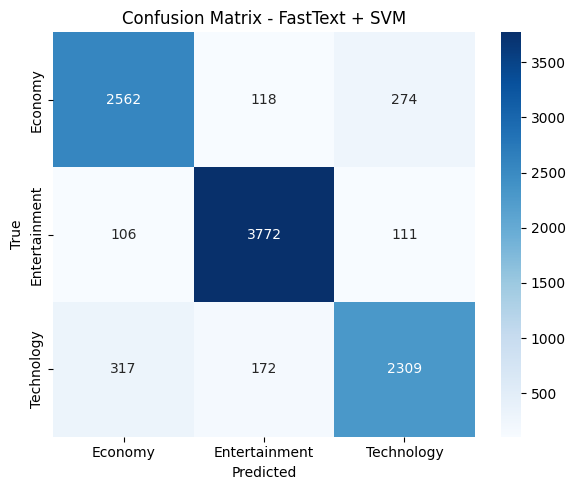

['models\\fasttext_model.joblib']

In [16]:

# =========================
# 13. EKSPERIMEN 3
#     FASTTEXT + SVM
# =========================
svm_ft = SVC(kernel="linear", C=1.0, probability=True, random_state=RANDOM_SEED)
svm_ft.fit(X_train_ft_vec, y_train_ft)

y_pred_ft = svm_ft.predict(X_test_ft_vec)

acc = accuracy_score(y_test_ft, y_pred_ft)
prec = precision_score(y_test_ft, y_pred_ft, average="macro", zero_division=0)
rec = recall_score(y_test_ft, y_pred_ft, average="macro", zero_division=0)
f1 = f1_score(y_test_ft, y_pred_ft, average="macro", zero_division=0)

print("\n=== FastText + SVM ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print(classification_report(y_test_ft, y_pred_ft, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test_ft, y_pred_ft)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - FastText + SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

joblib.dump(svm_ft, MODEL_DIR / "fasttext_svm.joblib")
joblib.dump(ft_model, MODEL_DIR / "fasttext_model.joblib")

In [17]:
# =========================
# 14. RINGKASAN HASIL EKSPERIMEN
# =========================
results = pd.DataFrame([
    {"model": "TF-IDF + Naive Bayes", **result_tfidf_nb},
    {"model": "TF-IDF + SVM", **result_tfidf_svm},
    {"model": "FastText + SVM", "accuracy": acc, "precision": prec, "recall": rec, "f1": f1},
])

print("\n=== HASIL PERBANDINGAN ===")
print(results.sort_values("f1", ascending=False))


=== HASIL PERBANDINGAN ===
                  model  accuracy  precision    recall        f1
1          TF-IDF + SVM  0.939123   0.935141  0.934604  0.934845
0  TF-IDF + Naive Bayes  0.924238   0.922205  0.916863  0.919184
2        FastText + SVM  0.887281   0.881329  0.879377  0.880219


In [ ]:
# # =========================
# # 15. INDOBERT FINE-TUNING
# # =========================
# # Catatan:
# # - Bagian ini butuh internet / model dari HuggingFace.
# # - Jika environment Anda terbatas, jalankan di Google Colab.
# # - Nama checkpoint bisa Anda sesuaikan dengan model IndoBERT yang tersedia.
# #   Contoh yang umum dipakai:
# #   "indobenchmark/indobert-base-p1"

# # !pip install -q transformers datasets accelerate torch

# from datasets import Dataset
# from transformers import (
#     AutoTokenizer,
#     AutoModelForSequenceClassification,
#     TrainingArguments,
#     Trainer,
#     DataCollatorWithPadding,
# )

# # preprocessing ringan untuk BERT:
# def preprocess_for_bert(text: str) -> str:
#     text = str(text).lower()
#     text = re.sub(r"https?://\S+|www\.\S+", " ", text)
#     text = re.sub(r"@\w+", " ", text)
#     text = re.sub(r"\s+", " ", text).strip()
#     return text

# df_bert = df[[TEXT_COL, "label_encoded"]].copy()
# df_bert["text_bert"] = df_bert[TEXT_COL].apply(preprocess_for_bert)

# train_df, test_df = train_test_split(
#     df_bert,
#     test_size=0.2,
#     random_state=RANDOM_SEED,
#     stratify=df_bert["label_encoded"]
# )

# train_ds = Dataset.from_pandas(train_df[["text_bert", "label_encoded"]].rename(
#     columns={"text_bert": "text", "label_encoded": "label"}
# ))
# test_ds = Dataset.from_pandas(test_df[["text_bert", "label_encoded"]].rename(
#     columns={"text_bert": "text", "label_encoded": "label"}
# ))

# MODEL_NAME = "indobenchmark/indobert-base-p1"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# def tokenize_function(batch):
#     return tokenizer(
#         batch["text"],
#         truncation=True,
#         padding=False,
#         max_length=128
#     )

# train_ds = train_ds.map(tokenize_function, batched=True)
# test_ds = test_ds.map(tokenize_function, batched=True)

# # agar Trainer tahu kolom mana yang dipakai
# train_ds = train_ds.remove_columns(["text"])
# test_ds = test_ds.remove_columns(["text"])

# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# bert_model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=len(class_names)
# )

# training_args = TrainingArguments(
#     output_dir=str(MODEL_DIR / "indobert_output"),
#     learning_rate=2e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="f1",
#     logging_dir=str(MODEL_DIR / "logs"),
#     report_to="none",
#     seed=RANDOM_SEED,
# )

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=-1)

#     return {
#         "accuracy": accuracy_score(labels, preds),
#         "precision": precision_score(labels, preds, average="macro", zero_division=0),
#         "recall": recall_score(labels, preds, average="macro", zero_division=0),
#         "f1": f1_score(labels, preds, average="macro", zero_division=0),
#     }

# trainer = Trainer(
#     model=bert_model,
#     args=training_args,
#     train_dataset=train_ds,
#     eval_dataset=test_ds,
#     tokenizer=tokenizer,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics,
# )

# # Jalankan training jika environment memungkinkan
# # trainer.train()

# # Evaluasi
# # bert_metrics = trainer.evaluate()
# # print(bert_metrics)

# # Prediksi
# # pred_output = trainer.predict(test_ds)
# # bert_preds = np.argmax(pred_output.predictions, axis=-1)
# # bert_y_true = pred_output.label_ids
# # print(classification_report(bert_y_true, bert_preds, target_names=class_names, zero_division=0))

# # cm = confusion_matrix(bert_y_true, bert_preds)
# # plt.figure(figsize=(6, 5))
# # sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
# #             xticklabels=class_names, yticklabels=class_names)
# # plt.title("Confusion Matrix - IndoBERT")
# # plt.xlabel("Predicted")
# # plt.ylabel("True")
# # plt.tight_layout()
# # plt.show()

# # Simpan model BERT jika sudah training
# # trainer.save_model(MODEL_DIR / "indobert_model")
# # tokenizer.save_pretrained(MODEL_DIR / "indobert_model")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/38963 [00:00<?, ? examples/s]

Map:   0%|          | 0/9741 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.035739,0.296737,14613,0.941074,0.937339,0.936703,0.937013



=== INDOBERT RESULTS ===
{'eval_loss': 0.2967374622821808, 'eval_accuracy': 0.9410738117236424, 'eval_precision': 0.9373389169631229, 'eval_recall': 0.9367033385323973, 'eval_f1': 0.9370134681027787}


               precision    recall  f1-score   support

      Economy       0.92      0.92      0.92      2954
Entertainment       0.97      0.97      0.97      3989
   Technology       0.92      0.91      0.92      2798

     accuracy                           0.94      9741
    macro avg       0.94      0.94      0.94      9741
 weighted avg       0.94      0.94      0.94      9741



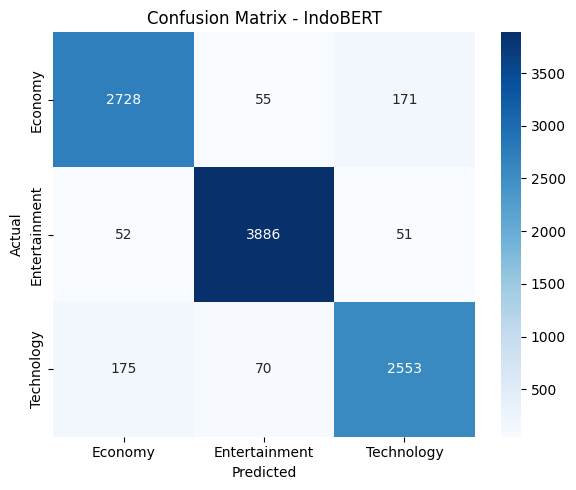

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models\\indobert_model\\tokenizer_config.json',
 'models\\indobert_model\\tokenizer.json')

In [22]:
# =========================
# 15. INDOBERT FINE-TUNING
# =========================

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

# =========================
# PREPROCESSING UNTUK BERT
# =========================
def preprocess_for_bert(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# =========================
# PREPARE DATASET
# =========================
df_bert = df[[TEXT_COL, "label_encoded"]].copy()

df_bert["text_bert"] = df_bert[TEXT_COL].apply(
    preprocess_for_bert
)

train_df, test_df = train_test_split(
    df_bert,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_bert["label_encoded"]
)

train_ds = Dataset.from_pandas(
    train_df[["text_bert", "label_encoded"]].rename(
        columns={
            "text_bert": "text",
            "label_encoded": "label"
        }
    )
)

test_ds = Dataset.from_pandas(
    test_df[["text_bert", "label_encoded"]].rename(
        columns={
            "text_bert": "text",
            "label_encoded": "label"
        }
    )
)

# =========================
# LOAD MODEL
# =========================
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(class_names)
)

# =========================
# TOKENIZATION
# =========================
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=128
    )

train_ds = train_ds.map(
    tokenize_function,
    batched=True
)

test_ds = test_ds.map(
    tokenize_function,
    batched=True
)

train_ds = train_ds.remove_columns(
    ["text"]
)

test_ds = test_ds.remove_columns(
    ["text"]
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# =========================
# METRICS
# =========================
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
    }

# =========================
# TRAINING ARGUMENTS
# =========================
training_args = TrainingArguments(
    output_dir="./indobert_output",

    num_train_epochs=3,

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    weight_decay=0.01,

    logging_steps=10,

    seed=RANDOM_SEED,
)

# =========================
# TRAINER
# =========================
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# =========================
# TRAIN
# =========================
trainer.train()

# =========================
# EVALUATION
# =========================
bert_metrics = trainer.evaluate()

print("\n=== INDOBERT RESULTS ===")
print(bert_metrics)

# =========================
# PREDICTION
# =========================
pred_output = trainer.predict(
    test_ds
)

bert_preds = np.argmax(
    pred_output.predictions,
    axis=1
)

bert_y_true = pred_output.label_ids

print(
    classification_report(
        bert_y_true,
        bert_preds,
        target_names=class_names,
        zero_division=0
    )
)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(
    bert_y_true,
    bert_preds
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - IndoBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# =========================
# SAVE MODEL
# =========================
trainer.save_model(
    MODEL_DIR / "indobert_model"
)

tokenizer.save_pretrained(
    MODEL_DIR / "indobert_model"
)

In [ ]:
# =========================
# 16. FUNGSI PREDIKSI SATU TEKS
# =========================
def predict_text_tfidf(model, text):
    cleaned = preprocess_classical(text)
    pred = model.predict([cleaned])[0]
    return le.inverse_transform([pred])[0]

def predict_text_fasttext(text):
    tokens = tokenize_for_fasttext(text)
    vec = sentence_vector_fasttext(tokens, ft_model)
    pred = svm_ft.predict([vec])[0]
    return le.inverse_transform([pred])[0]

print("\nContoh prediksi:")
print("TF-IDF + NB  :", predict_text_tfidf(tfidf_nb, "Harga cabai naik lagi di pasar"))
print("TF-IDF + SVM :", predict_text_tfidf(tfidf_svm, "Film baru itu sangat seru dan lucu"))
print("FastText + SVM:", predict_text_fasttext("Update terbaru dari smartphone ini sangat menarik"))

In [ ]:
# =========================
# 17. CATATAN PENYESUAIAN
# =========================
# - Jika dataset Anda masih mentah, pastikan kolom teks dan label sudah benar.
# - Jika label belum berupa 3 kelas yang Anda inginkan, lakukan mapping label terlebih dahulu.
# - Jika Anda ingin mempertahankan emoji atau hashtag tertentu, ubah fungsi clean_basic_text().
# - Jika Anda ingin mencoba n-gram lain, ubah ngram_range pada TfidfVectorizer.
# - Jika data sangat kecil, pertimbangkan cross-validation.